<a href="https://colab.research.google.com/github/danielmarin030513-ctrl/Ai-Project-TAM400-Daniel.M-Oskar.A/blob/main/Heart_Failure_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

In [ ]:
path = kagglehub.dataset_download(
    "fedesoriano/heart-failure-prediction"
)

print("Path to dataset files:", path)

In [ ]:
import os

os.listdir(path)

# **TEST**

In [ ]:
df = pd.read_csv(f"{path}/heart.csv")

In [ ]:
df.head()

In [ ]:
df.describe()

In [ ]:
print(df.isnull().sum())

In [ ]:
df['HeartDisease'].value_counts()

In [ ]:
import matplotlib.pyplot as plt

df['HeartDisease'].value_counts().plot(kind='bar')

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df[df['HeartDisease'] == 1]['Age'], alpha=0.7, label='Disease')
plt.hist(df[df['HeartDisease'] == 0]['Age'], alpha=0.7, label='No Disease')

plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()

In [ ]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

X = pd.get_dummies(X, drop_first=True)

print(X.head())

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [132]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Initialize a RandomForestClassifier (you can replace this with any model you want to tune)
model = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='recall', # Changed to 'recall' based on the output 'Best Recall'
    cv=3, # Using 3-fold cross-validation
    n_jobs=-1, # Use all available cores
    verbose=1 # Show progress
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Recall:")
print(grid_search.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}

Best Recall:
0.9014161220043574


In [133]:
rf_default = RandomForestClassifier(
    random_state=42
)

rf_default.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [134]:
y_pred_default = rf_default.predict(X_test)

y_pred_tuned = best_model.predict(X_test)

In [135]:
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))

print("Precision:", precision_score(y_test, y_pred_tuned))

print("Recall:", recall_score(y_test, y_pred_tuned))

print("F1-score:", f1_score(y_test, y_pred_tuned))

Accuracy: 0.8804347826086957
Precision: 0.8921568627450981
Recall: 0.8921568627450981
F1-score: 0.8921568627450981


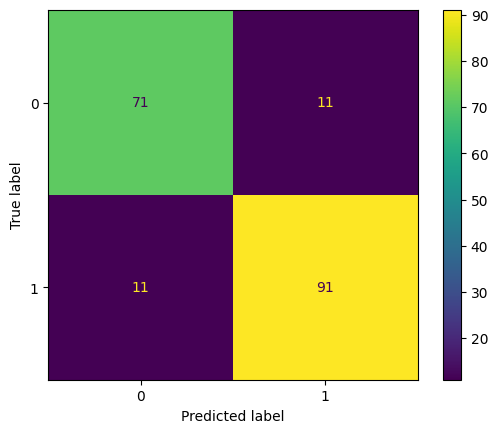

In [136]:
cm = confusion_matrix(y_test, y_pred_tuned)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

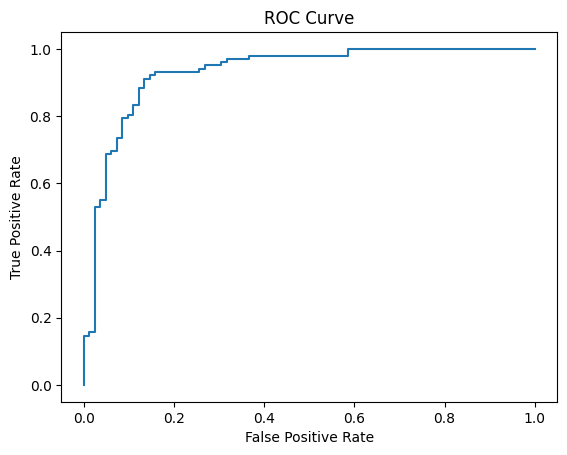

AUC: 0.9314921090387375


In [137]:
y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

print("AUC:", roc_auc_score(y_test, y_prob))

In [138]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87        82
           1       0.89      0.89      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



In [139]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

              Feature  Importance
14        ST_Slope_Up    0.195084
13      ST_Slope_Flat    0.135419
4               MaxHR    0.113493
5             Oldpeak    0.099090
12   ExerciseAngina_Y    0.092238
2         Cholesterol    0.087652
0                 Age    0.064011
1           RestingBP    0.063103
7   ChestPainType_ATA    0.039110
6               Sex_M    0.032231
8   ChestPainType_NAP    0.025106
3           FastingBS    0.025073
10  RestingECG_Normal    0.010953
9    ChestPainType_TA    0.009243
11      RestingECG_ST    0.008193


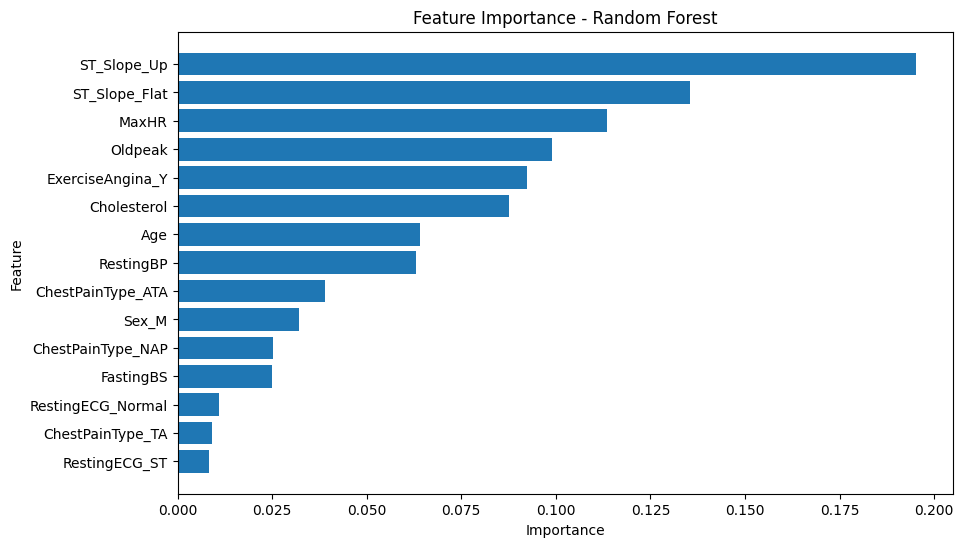

In [140]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")

plt.gca().invert_yaxis()
plt.show()

# KLAR

In [141]:
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [142]:
lr_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lr', LogisticRegression(max_iter=1000, random_state=42))])

In [143]:
y_pred_lr = lr_model.predict(X_test)
y_proba_lr = lr_model.predict_proba(X_test)[:,1]

In [144]:
print("Logistic Regression")

print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("AUC:",
      roc_auc_score(y_test, y_proba_lr))

print(classification_report(
    y_test,
    y_pred_lr
))

Logistic Regression
Accuracy: 0.8858695652173914
AUC: 0.9296987087517934
              precision    recall  f1-score   support

           0       0.91      0.83      0.87        82
           1       0.87      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



In [145]:
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

sgd_clf = make_pipeline(
    StandardScaler(),
    SGDClassifier(random_state=42)
)

sgd_clf.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('sgdclassifier', SGDClassifier(random_state=42))])

In [146]:
y_pred_sgd = sgd_clf.predict(X_test)

In [147]:
print("SGD Accuracy:",
      accuracy_score(y_test, y_pred_sgd))

print("\nSGD Classification Report:")
print(classification_report(y_test, y_pred_sgd))

SGD Accuracy: 0.8695652173913043

SGD Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86        82
           1       0.91      0.85      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



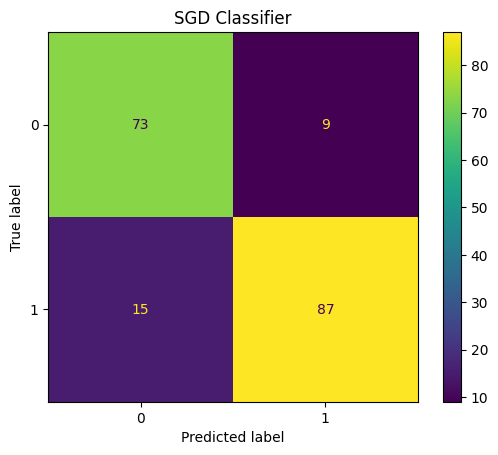

In [148]:
cm_sgd = confusion_matrix(y_test, y_pred_sgd)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_sgd
)

disp.plot()

plt.title("SGD Classifier")
plt.show()

In [149]:
print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_tuned))

print("SGD Accuracy:",
      accuracy_score(y_test, y_pred_sgd))

Random Forest Accuracy: 0.8804347826086957
SGD Accuracy: 0.8695652173913043


In [150]:
y_pred_default = rf_default.predict(X_test)

y_pred_tuned = best_model.predict(X_test)

In [151]:
print("Default RF Accuracy:",
      accuracy_score(y_test, y_pred_default))

print("Tuned RF Accuracy:",
      accuracy_score(y_test, y_pred_tuned))

Default RF Accuracy: 0.875
Tuned RF Accuracy: 0.8804347826086957


In [152]:
y_pred_tuned = best_model.predict(X_test)

In [153]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87        82
           1       0.89      0.89      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



In [155]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Logistic Regression",
        "SGD"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_tuned),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_sgd)
    ],
    "Precision": [
        precision_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_sgd)
    ],
    "Recall": [
        recall_score(y_test, y_pred_tuned),
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_sgd)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_tuned),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_sgd)
    ]
})

results.sort_values(
    by="Recall",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-score
1,Logistic Regression,0.885870,0.871560,0.931373,0.900474
0,Random Forest,0.880435,0.892157,0.892157,0.892157
2,SGD,0.869565,0.906250,0.852941,0.878788
